# E-Commerce Data Analysis

Este notebook contiene el análisis principal del proyecto utilizando MongoDB, Aggregation Pipelines, Pandas y visualizaciones en Python.

El objetivo es validar la información cargada en MongoDB, calcular los principales indicadores de negocio, analizar tendencias y generar hallazgos útiles a partir del dataset.

## 1. Configuración y conexión a MongoDB

In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
MONGODB_URI = "mongodb://localhost:27017"
DATABASE_NAME = "ecommerce_analytics"

client = MongoClient(MONGODB_URI)
db = client[DATABASE_NAME]

client.admin.command("ping")

print("Conexión a MongoDB correcta.")
print("Colecciones disponibles:")
print(db.list_collection_names())

Conexión a MongoDB correcta.
Colecciones disponibles:
['times', 'sales', 'stores', 'items', 'payments', 'customers']


## 2. Validación de colecciones

In [3]:
collections = [
    "customers",
    "items",
    "stores",
    "times",
    "payments",
    "sales"
]

for collection_name in collections:
    count = db[collection_name].count_documents({})
    print(f"{collection_name}: {count:,}")

customers: 9,191
items: 264
stores: 726
times: 99,999
payments: 39
sales: 1,000,000


## 3. Indicadores principales

In [4]:
pipeline = [
    {
        "$group": {
            "_id": None,
            "total_sales": {"$sum": "$total_price"},
            "transactions": {"$sum": 1},
            "unique_customers": {"$addToSet": "$customer_key"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "total_sales": 1,
            "transactions": 1,
            "unique_customers": {"$size": "$unique_customers"},
            "average_ticket": {
                "$divide": ["$total_sales", "$transactions"]
            }
        }
    }
]

kpis = list(db.sales.aggregate(pipeline))[0]

print(f"Venta total: {kpis['total_sales']:,.2f}")
print(f"Número de transacciones: {kpis['transactions']:,}")
print(f"Clientes únicos: {kpis['unique_customers']:,}")
print(f"Ticket promedio: {kpis['average_ticket']:,.2f}")

Venta total: 105,401,435.75
Número de transacciones: 1,000,000
Clientes únicos: 9,191
Ticket promedio: 105.40


## 4. Evolución de ventas

In [5]:
pipeline = [
    {
        "$lookup": {
            "from": "times",
            "localField": "time_key",
            "foreignField": "time_key",
            "as": "time_info"
        }
    },
    {
        "$unwind": "$time_info"
    },
    {
        "$group": {
            "_id": {
                "year": "$time_info.year",
                "month": "$time_info.month"
            },
            "total_sales": {
                "$sum": "$total_price"
            }
        }
    },
    {
        "$sort": {
            "_id.year": 1,
            "_id.month": 1
        }
    }
]

sales_evolution = list(db.sales.aggregate(pipeline))

In [6]:
df_sales_evolution = pd.DataFrame([
    {
        "year": row["_id"]["year"],
        "month": row["_id"]["month"],
        "total_sales": row["total_sales"]
    }
    for row in sales_evolution
])

df_sales_evolution.head(12)

,year,month,total_sales
0,2014,1,496549.25
1,2014,2,1122547.00
2,2014,3,1262435.75
3,2014,4,1245142.50
4,2014,5,1268770.50
5,2014,6,1240771.75
6,2014,7,1317296.00
7,2014,8,1293211.00
8,2014,9,1279444.25
9,2014,10,1299793.50


In [7]:
df_sales_evolution["date"] = pd.to_datetime(
    dict(
        year=df_sales_evolution["year"],
        month=df_sales_evolution["month"],
        day=1
    )
)

df_sales_evolution.head()

,year,month,total_sales,date
0,2014,1,496549.25,2014-01-01
1,2014,2,1122547.00,2014-02-01
2,2014,3,1262435.75,2014-03-01
3,2014,4,1245142.50,2014-04-01
4,2014,5,1268770.50,2014-05-01


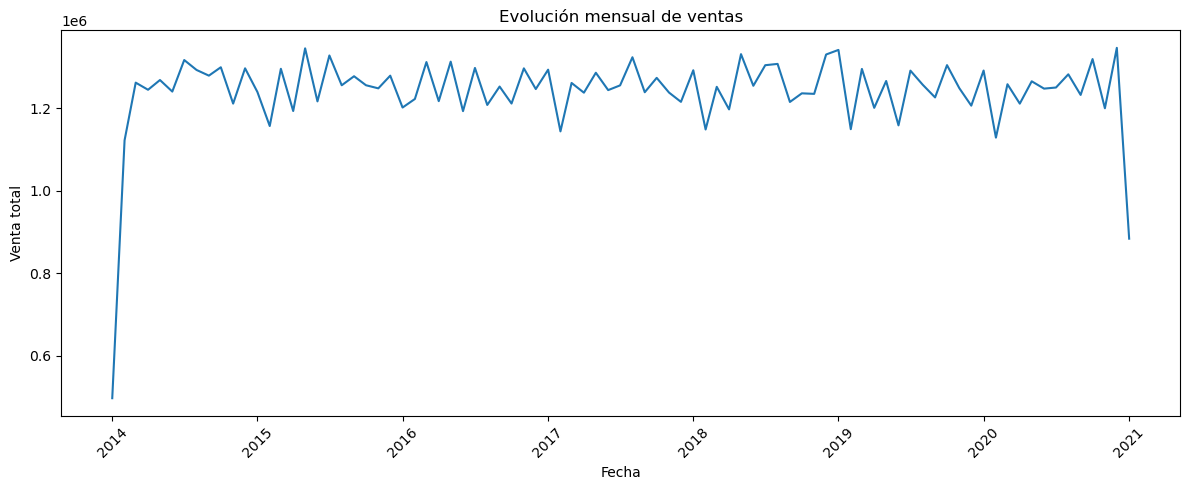

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_sales_evolution["date"],
    df_sales_evolution["total_sales"]
)

plt.title("Evolución mensual de ventas")
plt.xlabel("Fecha")
plt.ylabel("Venta total")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 5. Comparación de tiendas

In [9]:
pipeline = [
    {
        "$group": {
            "_id": "$store_key",
            "total_sales": {
                "$sum": "$total_price"
            },
            "transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$lookup": {
            "from": "stores",
            "localField": "_id",
            "foreignField": "store_key",
            "as": "store_info"
        }
    },
    {
        "$unwind": "$store_info"
    },
    {
        "$project": {
            "_id": 0,
            "store_key": "$_id",
            "division": "$store_info.division",
            "district": "$store_info.district",
            "upazila": "$store_info.upazila",
            "total_sales": 1,
            "transactions": 1
        }
    },
    {
        "$sort": {
            "total_sales": -1
        }
    }
]

sales_by_store = list(db.sales.aggregate(pipeline))

df_sales_by_store = pd.DataFrame(sales_by_store)

df_sales_by_store.head(10)

,total_sales,transactions,store_key,division,district,upazila
0,159409.00,1437,S0010,SYLHET,MAULVIBAZAR,JURI
1,158027.50,1448,S00601,DHAKA,DHAKA,DARUS SALAM
2,157692.00,1450,S00328,DHAKA,MADARIPUR,SHIBCHAR
3,157483.00,1497,S0039,RANGPUR,DINAJPUR,BIRAMPUR
4,157377.50,1465,S0080,RANGPUR,PANCHAGARH,BODA
5,157243.50,1450,S00357,DHAKA,NARAYANGANJ,BANDAR
6,156979.50,1467,S00411,CHITTAGONG,BRAHMANBARIA,AKHAURA
7,156793.75,1464,S00708,CHITTAGONG,CHITTAGONG,PAHARTALI
8,156767.75,1446,S00687,DHAKA,DHAKA,UTTARA PURBA
9,156651.50,1407,S00266,DHAKA,DHAKA,PALLABI


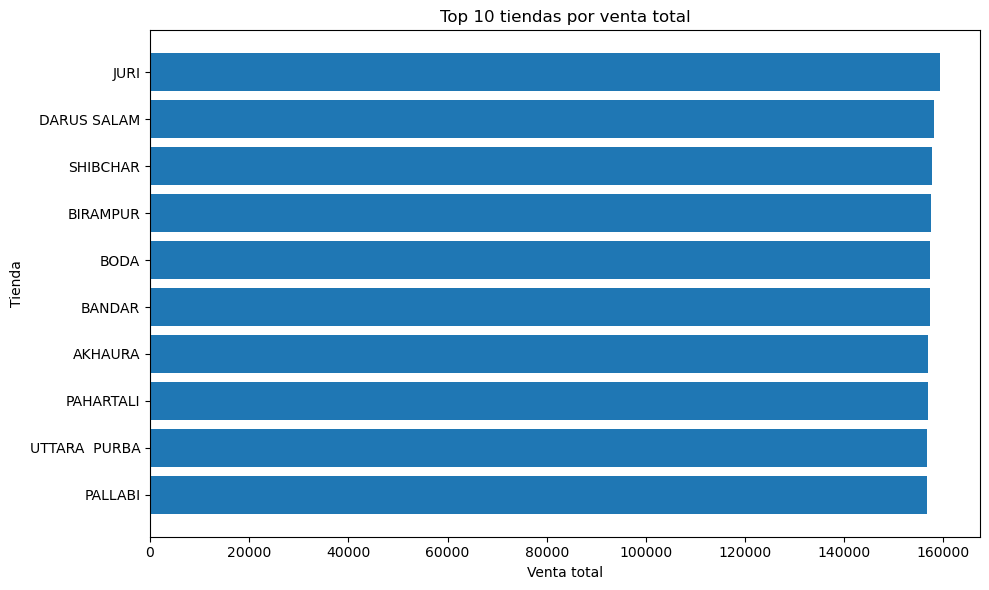

In [10]:
top_stores = df_sales_by_store.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_stores["upazila"],
    top_stores["total_sales"]
)

plt.title("Top 10 tiendas por venta total")
plt.xlabel("Venta total")
plt.ylabel("Tienda")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## 6. Comparación de productos

In [11]:
pipeline = [
    {
        "$group": {
            "_id": "$item_key",
            "total_sales": {
                "$sum": "$total_price"
            },
            "quantity_sold": {
                "$sum": "$quantity"
            },
            "transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$lookup": {
            "from": "items",
            "localField": "_id",
            "foreignField": "item_key",
            "as": "item_info"
        }
    },
    {
        "$unwind": "$item_info"
    },
    {
        "$project": {
            "_id": 0,
            "item_key": "$_id",
            "item_name": "$item_info.item_name",
            "supplier": "$item_info.supplier",
            "total_sales": 1,
            "quantity_sold": 1,
            "transactions": 1
        }
    },
    {
        "$sort": {
            "total_sales": -1
        }
    }
]

sales_by_product = list(db.sales.aggregate(pipeline))

df_sales_by_product = pd.DataFrame(sales_by_product)

df_sales_by_product.head(10)

,total_sales,quantity_sold,transactions,item_key,item_name,supplier
0,1305700.0,23740,3911,I00061,Red Bull 12oz,MAESA SAS
1,1245394.0,23498,3883,I00115,K Cups Daily Chef Columbian Supremo,Indo Count Industries Ltd
2,1188843.0,22431,3763,I00119,K Cups Original Donut Shop Med. Roast,Indo Count Industries Ltd
3,1109760.0,23120,3871,I00116,K Cups Dunkin Donuts Medium Roast,MAESA SAS
4,1042406.0,22661,3812,I00117,K Cups Folgers Lively Columbian,NINGBO SEDUNO IMP & EXP CO.LTD
5,1012995.0,22511,3759,I00123,Honey Packets,Bolsius Boxmeer
6,995456.0,22624,3780,I00114,K Cups  Starbuck's Pike Place,BIGSO AB
7,957516.0,22798,3747,I00118,K Cups Organic Breakfast Blend,HARDFORD AB
8,956886.0,22783,3815,I00113,K Cups - McCafe Premium Roast,Indo Count Industries Ltd
9,933720.0,23343,3827,I00064,Red Bull Sugar Free 8.4 oz,BIGSO AB


C:\Users\LEGION\AppData\Local\Temp\ipykernel_17648\4055486299.py:15: UserWarning: Glyph 150 (\x96) missing from current font.
  plt.tight_layout()
D:\Anaconda\IAnaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 150 (\x96) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


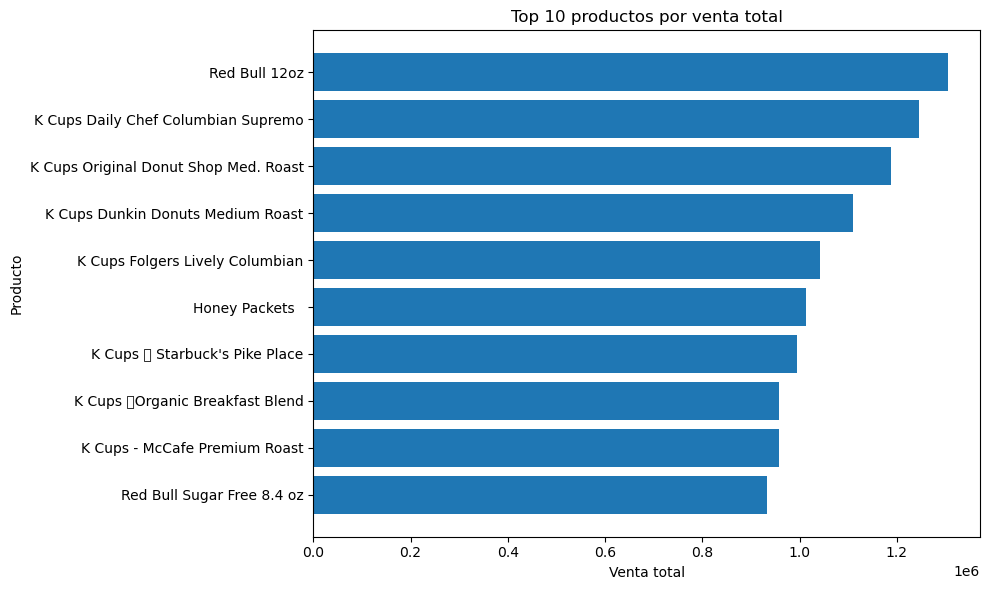

In [12]:
top_products = df_sales_by_product.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["item_name"],
    top_products["total_sales"]
)

plt.title("Top 10 productos por venta total")
plt.xlabel("Venta total")
plt.ylabel("Producto")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## 7. Análisis por método de pago

In [13]:
pipeline = [
    {
        "$group": {
            "_id": "$payment_key",
            "total_sales": {
                "$sum": "$total_price"
            },
            "transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$lookup": {
            "from": "payments",
            "localField": "_id",
            "foreignField": "payment_key",
            "as": "payment_info"
        }
    },
    {
        "$unwind": "$payment_info"
    },
    {
        "$project": {
            "_id": 0,
            "payment_key": "$_id",
            "transaction_type": "$payment_info.transaction_type",
            "bank_name": "$payment_info.bank_name",
            "total_sales": 1,
            "transactions": 1
        }
    },
    {
        "$sort": {
            "total_sales": -1
        }
    }
]

sales_by_payment = list(db.sales.aggregate(pipeline))

df_sales_by_payment = pd.DataFrame(sales_by_payment)

df_sales_by_payment.head(10)

,total_sales,transactions,payment_key,transaction_type,bank_name
0,2730999.25,25787,P003,card,Bangladesh Commerce Bank Limited
1,2728515.50,26046,P002,card,AB Bank Limited
2,2728366.00,25839,P009,card,Dhaka Bank Limited
3,2728115.25,25964,P032,card,South Bangla Agriculture and Commerce Bank Lim...
4,2727661.00,25853,P029,card,Standard Bank Limited
5,2723363.00,25849,P020,card,National Credit & Commerce Bank Limited
6,2723215.25,25580,P006,card,Citizens Bank Limited
7,2720974.50,25865,P038,mobile,Rocket
8,2720807.00,25661,P033,card,Trust Bank Limited
9,2715279.00,25749,P017,card,Modhumoti Bank Limited


In [14]:
payment_summary = (
    df_sales_by_payment
    .groupby("transaction_type", as_index=False)
    .agg({
        "total_sales": "sum",
        "transactions": "sum"
    })
    .sort_values("total_sales", ascending=False)
)

payment_summary

,transaction_type,total_sales,transactions
0,card,94583038.50,897319
2,mobile,8109881.50,77091
1,cash,2708515.75,25590


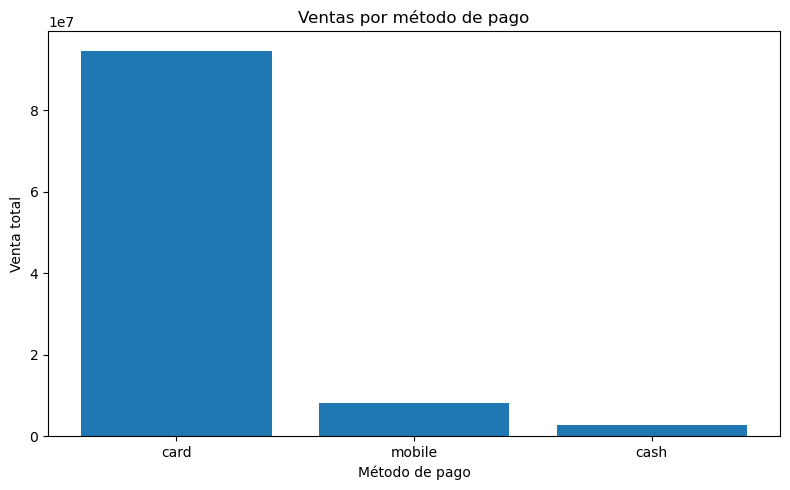

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_summary["transaction_type"],
    payment_summary["total_sales"]
)

plt.title("Ventas por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Venta total")

plt.tight_layout()
plt.show()

## 8. Validaciones y posibles anomalías

In [16]:
pipeline = [
    {
        "$group": {
            "_id": None,
            "min_sale": {"$min": "$total_price"},
            "max_sale": {"$max": "$total_price"},
            "avg_sale": {"$avg": "$total_price"}
        }
    }
]

sale_stats = list(db.sales.aggregate(pipeline))[0]

print(f"Venta mínima: {sale_stats['min_sale']:,.2f}")
print(f"Venta máxima: {sale_stats['max_sale']:,.2f}")
print(f"Venta promedio: {sale_stats['avg_sale']:,.2f}")

Venta mínima: 6.00
Venta máxima: 605.00
Venta promedio: 105.40


## 9. Consumo de API pública

In [17]:
url = "https://dummyjson.com/products"

response = requests.get(url, timeout=10)
response.raise_for_status()

data = response.json()

df_api = pd.DataFrame(data["products"])[
    ["id", "title", "category", "price", "rating"]
]

df_api.head(10)

,id,title,category,price,rating
0,1,Essence Mascara Lash Princess,beauty,9.99,2.56
1,2,Eyeshadow Palette with Mirror,beauty,19.99,2.86
2,3,Powder Canister,beauty,14.99,4.64
3,4,Red Lipstick,beauty,12.99,4.36
4,5,Red Nail Polish,beauty,8.99,4.32
5,6,Calvin Klein CK One,fragrances,49.99,4.37
6,7,Chanel Coco Noir Eau De,fragrances,129.99,4.26
7,8,Dior J'adore,fragrances,89.99,3.80
8,9,Dolce Shine Eau de,fragrances,69.99,3.96
9,10,Gucci Bloom Eau de,fragrances,79.99,2.74


## 10. Salida ejecutiva
Parte III - Visualización y análisis de negocio

Esta sección consolida los principales resultados del análisis y permite observar la situación general de ventas, su evolución y el comportamiento de productos, tiendas y métodos de pago.

In [18]:
print("RESUMEN GENERAL")
print("-" * 45)

print(f"Venta total: {kpis['total_sales']:,.2f}")
print(f"Número de transacciones: {kpis['transactions']:,}")
print(f"Clientes únicos: {kpis['unique_customers']:,}")
print(f"Ticket promedio: {kpis['average_ticket']:,.2f}")

RESUMEN GENERAL
---------------------------------------------
Venta total: 105,401,435.75
Número de transacciones: 1,000,000
Clientes únicos: 9,191
Ticket promedio: 105.40


### Segmentación por año

Se utiliza el año como criterio de segmentación para observar el comportamiento de las ventas dentro de un periodo específico.

In [19]:
selected_year = 2019

df_year = df_sales_evolution[
    df_sales_evolution["year"] == selected_year
].copy()

df_year

,year,month,total_sales,date
60,2019,1,1341867.00,2019-01-01
61,2019,2,1149508.50,2019-02-01
62,2019,3,1295730.00,2019-03-01
63,2019,4,1201298.00,2019-04-01
64,2019,5,1266431.50,2019-05-01
65,2019,6,1158766.00,2019-06-01
66,2019,7,1291609.75,2019-07-01
67,2019,8,1257271.75,2019-08-01
68,2019,9,1226580.50,2019-09-01
69,2019,10,1304910.25,2019-10-01


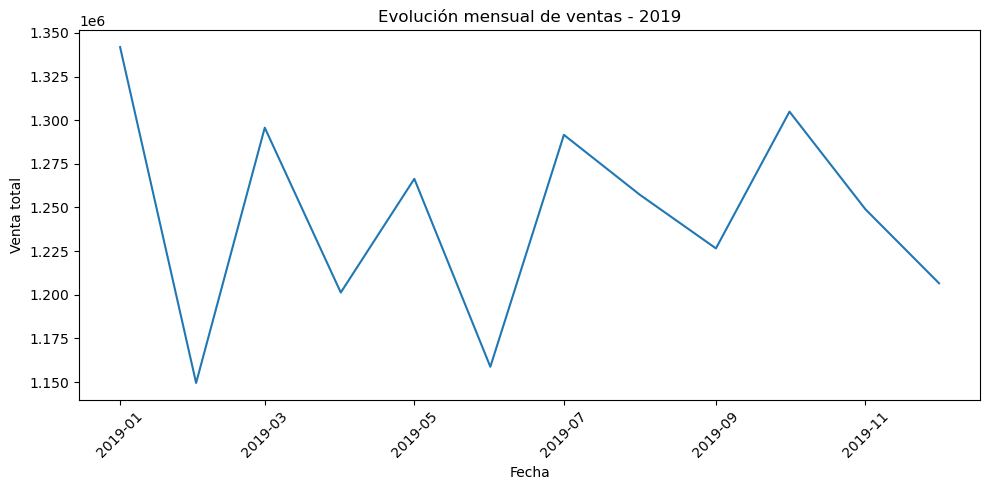

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_year["date"],
    df_year["total_sales"]
)

plt.title(f"Evolución mensual de ventas - {selected_year}")
plt.xlabel("Fecha")
plt.ylabel("Venta total")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Principales resultados

- `Red Bull 12oz` fue el producto con mayor venta total.
- Las tiendas líderes presentan niveles de venta relativamente cercanos entre sí.
- El método de pago predominante es `card`, muy por encima de `mobile` y `cash`.
- La evolución mensual muestra variaciones a lo largo del periodo, aunque sin cambios extremos sostenidos durante la mayor parte del análisis.

### Conclusión ejecutiva

El análisis muestra un volumen total de ventas de 105,401,435.75 distribuido en 1,000,000 de transacciones, con 9,191 clientes únicos y un ticket promedio de 105.40.

La segmentación por año permite analizar periodos específicos sin necesidad de trabajar nuevamente con todas las transacciones.

A nivel comercial, destacan la alta participación de los pagos con tarjeta, el liderazgo de `Red Bull 12oz` por venta total y un desempeño relativamente equilibrado entre las tiendas con mayores ventas.

Estos resultados pueden servir como punto de partida para análisis posteriores relacionados con rentabilidad, inventario, comportamiento de clientes y desempeño por ubicación.